In [2]:
%pip install torch torchvision matplotlib scikit-learn numpy

   ---------------------------------------- 0.0/204.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/204.1 MB 5.6 MB/s eta 0:00:37
    --------------------------------------- 5.0/204.1 MB 18.9 MB/s eta 0:00:11
   - -------------------------------------- 7.9/204.1 MB 16.8 MB/s eta 0:00:12
   -- ------------------------------------- 11.0/204.1 MB 15.6 MB/s eta 0:00:13
   --- ------------------------------------ 19.9/204.1 MB 22.1 MB/s eta 0:00:09
   ----- ---------------------------------- 29.9/204.1 MB 26.7 MB/s eta 0:00:07
   ------- -------------------------------- 37.5/204.1 MB 28.4 MB/s eta 0:00:06
   --------- ------------------------------ 46.7/204.1 MB 30.3 MB/s eta 0:00:06
   ---------- ----------------------------- 54.8/204.1 MB 31.4 MB/s eta 0:00:05
   ------------ --------------------------- 65.5/204.1 MB 33.4 MB/s eta 0:00:05
   -------------- ------------------------- 75.5/204.1 MB 34.9 MB/s eta 0:00:04
   ---------------- ----------------------- 82.3/204.

In [3]:
"""
fashionmnist_cnn.py

This script demonstrates:
1. Loading and preprocessing the FashionMNIST dataset.
2. Building a baseline CNN.
3. Training the model and plotting loss curves.
4. Evaluating with test accuracy and a confusion matrix.
5. Experimentation: adding more layers, dropout, or data augmentation.
"""

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
# ----------------------------
# 1. DATA PREPROCESSING
# ----------------------------

# For baseline: just convert PIL images to tensors in [0,1].
# For an improved version, you can add data augmentation (see Part 4).
transform_baseline = transforms.Compose([
    transforms.ToTensor()
])

# Example data augmentation transform (uncomment if you want to try it):
# transform_augmented = transforms.Compose([
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomRotation(10),
#     transforms.ToTensor()
# ])

# Download and load the training data
train_val_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_baseline  # or transform_augmented for improvements
)

# Download and load the test data
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform_baseline
)

# Split training set into train & validation subsets (80-20 split, for example)
train_size = int(0.8 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size
train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


100.0%
100.0%
100.0%
100.0%


In [5]:
# ----------------------------
# 2. BUILDING THE CNN MODEL
# ----------------------------

class BaselineCNN(nn.Module):
    """
    A simple baseline CNN with:
    - 2 convolutional layers (3x3 kernel)
    - 1 pooling layer
    - 1 fully connected layer
    - ReLU activations
    - Softmax (through CrossEntropyLoss)
    """
    def __init__(self, num_classes=10):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 14 * 14, 128)  # after pooling, input is 64@14x14
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        # (N, 1, 28, 28) -> (N, 32, 28, 28)
        x = self.relu(self.conv1(x))
        # (N, 32, 28, 28) -> (N, 64, 28, 28)
        x = self.relu(self.conv2(x))
        # pooling: (N, 64, 28, 28) -> (N, 64, 14, 14)
        x = self.pool(x)
        # flatten for the fully connected layer
        x = x.view(x.size(0), -1)  # (N, 64*14*14)
        x = self.relu(self.fc1(x)) # (N, 128)
        x = self.fc2(x)            # (N, num_classes)
        return x

# For an improved model, you might add dropout, batchnorm, or more layers:
# class ImprovedCNN(nn.Module):
#     # Example with an extra conv layer, dropout, or batchnorm
#     def __init__(self, num_classes=10):
#         super(ImprovedCNN, self).__init__()
#         self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
#         self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
#         self.pool = nn.MaxPool2d(2, 2)
#         self.dropout = nn.Dropout(0.25)
#         self.bn64 = nn.BatchNorm2d(64)
#         self.fc1 = nn.Linear(64 * 14 * 14, 128)
#         self.fc2 = nn.Linear(128, num_classes)
#         self.relu = nn.ReLU()
# 
#     def forward(self, x):
#         x = self.relu(self.conv1(x))
#         x = self.relu(self.conv2(x))
#         x = self.conv3(x)
#         x = self.bn64(x)
#         x = self.relu(x)
#         x = self.pool(x)
#         x = self.dropout(x)
#         x = x.view(x.size(0), -1)
#         x = self.relu(self.fc1(x))
#         x = self.fc2(x)
#         return x


In [6]:
# ----------------------------
# 3. TRAINING & EVALUATION
# ----------------------------

def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=5, device='cpu'):
    model.to(device)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()  # enable training mode
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validate
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {epoch_train_loss:.4f}, "
              f"Val Loss: {epoch_val_loss:.4f}")

    # Plot the training/validation loss curves
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title("Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

def test_model(model, test_loader, device='cpu'):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100.0 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    # Generate confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=range(10))  # 10 classes
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

Using device: cpu
Epoch [1/10], Train Loss: 0.4225, Val Loss: 0.3044
Epoch [2/10], Train Loss: 0.2551, Val Loss: 0.2619
Epoch [3/10], Train Loss: 0.2022, Val Loss: 0.2441
Epoch [4/10], Train Loss: 0.1588, Val Loss: 0.2310
Epoch [5/10], Train Loss: 0.1280, Val Loss: 0.2253
Epoch [6/10], Train Loss: 0.0986, Val Loss: 0.2460
Epoch [7/10], Train Loss: 0.0748, Val Loss: 0.2788
Epoch [8/10], Train Loss: 0.0555, Val Loss: 0.3176
Epoch [9/10], Train Loss: 0.0397, Val Loss: 0.3491
Epoch [10/10], Train Loss: 0.0359, Val Loss: 0.3439


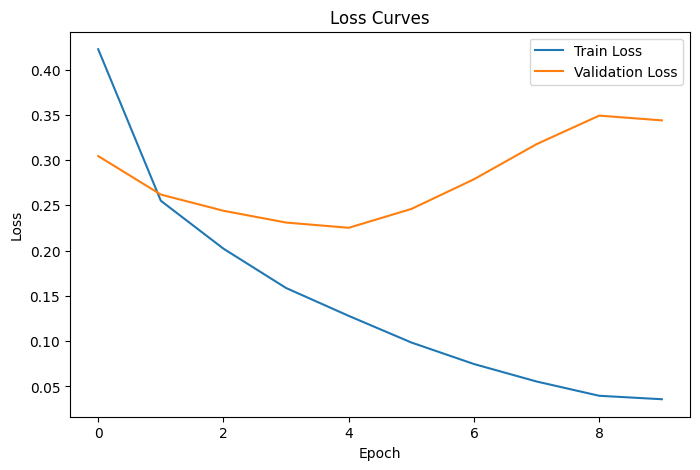

Test Accuracy: 92.01%


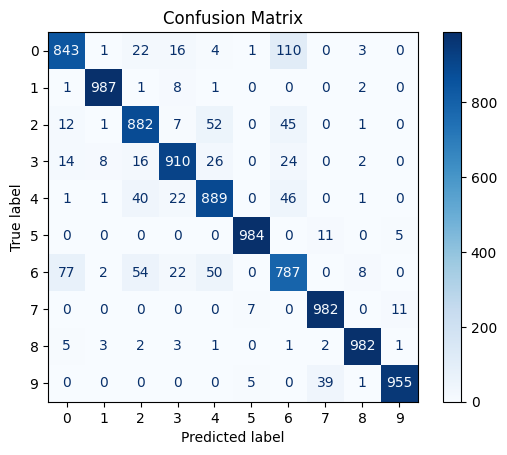

In [7]:
# ----------------------------
# 4. MAIN SCRIPT (Putting it all together)
# ----------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Build baseline model
    model = BaselineCNN(num_classes=10)

    # Loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Train the baseline model
    train_model(model, criterion, optimizer,
                train_loader, val_loader,
                num_epochs=10,
                device=device)

    # Evaluate the baseline model
    test_model(model, test_loader, device=device)

    # OPTIONAL: If you want to try an improved model, uncomment and run:
    # improved_model = ImprovedCNN(num_classes=10)
    # improved_criterion = nn.CrossEntropyLoss()
    # improved_optimizer = optim.Adam(improved_model.parameters(), lr=0.001)
    # train_model(improved_model, improved_criterion, improved_optimizer,
    #             train_loader, val_loader,
    #             num_epochs=10,
    #             device=device)
    # test_model(improved_model, test_loader, device=device)